In [2]:
!pip install kagglehub

  Obtaining dependency information for kagglehub from https://files.pythonhosted.org/packages/70/14/7b1f40778a4c8930f46b5841902647396069ccaa21cb8e0779ee822ffa77/kagglehub-1.0.1-py3-none-any.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.3 MB/s eta 0:00:00
  Obtaining dependency information for kagglesdk<1.0,>=0.1.22 from https://files.pythonhosted.org/packages/8f/4e/fead499e4e76f66203611ecee1032fc8da87f2ab59c3921c76b06334cbbf/kagglesdk-0.1.23-py3-none-any.whl.metadata
  Obtaining dependency information for tqdm from https://files.pythonhosted.org/packages/16/e1/3079a9ff9b8e11b846c6ac5c8b5bfb7ff225eee721825310c91b3b50304f/tqdm-4.67.3-py3-none-any.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.8/217.8 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 37.1 MB/

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import kagglehub
import glob

2026-05-23 17:40:51.643315: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-23 17:40:51.686656: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-23 17:40:51.686686: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-23 17:40:51.686721: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-23 17:40:51.695679: I tensorflow/core/platform/cpu_feature_g

# Dataset Loading

In [4]:
path = kagglehub.dataset_download("kmljts/reside-6k", output_dir="/tf/data/reside")

100%|██████████| 1.48G/1.48G [00:48<00:00, 33.1MB/s]

Extracting files...


In [2]:
def load_pair(img_path, ground_truth_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [400, 400])

    gt = tf.io.read_file(ground_truth_path)
    gt = tf.image.decode_jpeg(gt, channels=3)
    gt = tf.image.resize(gt, [400, 400])

    return img, gt

def make_dataset(split, path):
    img_paths  = sorted(glob.glob(f"/{path}/reside/RESIDE-6K/{split}/hazy/*.jpg"))
    gt_paths = sorted(glob.glob(f"/{path}/reside/RESIDE-6K/{split}/GT/*.jpg"))

    ds = tf.data.Dataset.from_tensor_slices((img_paths, gt_paths))
    ds = ds.map(load_pair, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [3]:
def preprocess(hazy, clean):
    hazy = tf.cast(hazy, tf.float32) / 255.0
    clean = tf.cast(clean, tf.float32) / 255.0
    return hazy, clean

In [4]:
def preprocess_validation(hazy, clean):
    hazy = tf.image.resize(hazy, [256, 256])
    clean = tf.image.resize(clean, [256, 256])
    return hazy, clean

In [5]:
def augment(hazy, clean):
    combined = tf.concat([hazy, clean], axis=-1)

    combined = tf.image.random_flip_left_right(combined)
    combined = tf.image.random_flip_up_down(combined)

    crop_size = tf.random.uniform([], minval=256, maxval=400, dtype=tf.int32)
    combined = tf.image.random_crop(combined, size=[crop_size, crop_size, 6])
    combined = tf.image.resize(combined, [256, 256])

    hazy = combined[..., :3]
    clean = combined[..., 3:]

    return hazy, clean

In [51]:
print(path)

/tf/data/reside


In [6]:
train_raw = make_dataset("train", path)
test_raw = make_dataset("test", path)

train_ds = train_raw.take(int(len(train_raw) * 0.85)).map(preprocess, num_parallel_calls=tf.data.AUTOTUNE).map(augment, num_parallel_calls=tf.data.AUTOTUNE).batch(32).cache().prefetch(tf.data.AUTOTUNE)

val_ds = train_raw.skip(int(len(train_raw) * 0.85)).take(int(len(train_raw) * 0.15)).map(preprocess, num_parallel_calls=tf.data.AUTOTUNE).map(preprocess_validation, num_parallel_calls=tf.data.AUTOTUNE).batch(32).cache().prefetch(tf.data.AUTOTUNE)

test_ds = test_raw.batch(32).map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

# God what have I done

2026-05-23 17:41:09.881657: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22363 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:4f:00.0, compute capability: 8.6


# Model Definition

In [7]:
def psnr_metric(y_true, y_pred):
    return tf.image.psnr(y_true, y_pred, max_val=1.0)

def ssim_metric(y_true, y_pred):
    return tf.image.ssim(y_true, y_pred, max_val=1.0)

In [8]:
def EncoderBlock(filters, inputs):
    x = layers.Conv2D(filters, 3, padding="same")(inputs)
    x = layers.Activation("relu")(x)
    return x

In [9]:
def DecoderBlock(filters, inputs):
    x = layers.Conv2D(filters, 3, padding="same")(inputs)
    x = layers.Activation("relu")(x)
    return x

In [10]:
inputs = layers.Input(shape=(256, 256, 3))
x = EncoderBlock(64, inputs)
x = EncoderBlock(64, x)

sk1 = x
x = layers.MaxPool2D(pool_size=(2, 2), strides=2)(x)

x = EncoderBlock(128, x)
x = EncoderBlock(128, x)

sk2 = x
x = layers.MaxPool2D(pool_size=(2, 2), strides=2)(x)

x = EncoderBlock(256, x)
x = EncoderBlock(256, x)

sk3 = x
x = layers.MaxPool2D(pool_size=(2, 2), strides=2)(x)

x = EncoderBlock(512, x)
x = EncoderBlock(512, x)

sk4 = x
x = layers.MaxPool2D(pool_size=(2, 2), strides=2)(x)

x = DecoderBlock(768, x)
x = DecoderBlock(768, x)

x = layers.UpSampling2D(size=(2, 2))(x)
x = layers.Concatenate()([x, sk4])

x = DecoderBlock(512, x)
x = DecoderBlock(512, x)

x = layers.UpSampling2D(size=(2, 2))(x)
x = layers.Concatenate()([x, sk3])

x = DecoderBlock(256, x)
x = DecoderBlock(256, x)

x = layers.UpSampling2D(size=(2, 2))(x)
x = layers.Concatenate()([x, sk2])

x = DecoderBlock(128, x)
x = DecoderBlock(128, x)


x = layers.UpSampling2D(size=(2, 2))(x)
x = layers.Concatenate()([x, sk1])

x = DecoderBlock(64, x)
x = DecoderBlock(64, x)

x = layers.Conv2D(3, 1, activation="tanh", padding="same")(x)
x = layers.Add()([x, inputs])
outputs = layers.Lambda(lambda x: tf.clip_by_value(x, 0, 1))(x)

In [11]:
model = keras.Model(inputs, outputs)

# Model Training

In [13]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    start_from_epoch=20
)

In [14]:
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    start_from_epoch=10,
    min_lr=1e-6
)

In [15]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="unet_weights/model_{epoch:02d}.keras",
    save_freq="epoch",
    verbose=1
)

In [16]:
def combined_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    ssim = 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))
    return 0.5 * mse + 0.5 * ssim

In [17]:
model.compile(
    optimizer="adam",
    loss=combined_loss,
    metrics=[psnr_metric, ssim_metric]
)

In [ ]:
model.summary()

In [21]:
model.fit(train_ds, validation_data=val_ds, epochs=100, callbacks=[early_stopping, reduce_lr, checkpoint])

Epoch 1/100


2026-05-23 17:41:59.883062: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8905
2026-05-23 17:42:00.016250: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-23 17:42:03.862426: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-23 17:42:06.369248: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7ed276f45f20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-23 17:42:06.369281: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A5000, Compute Capability 8.6
2026-05-23 17:42:06.374422: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-23 17:42:06.485983: I ./tensorflow/compiler/jit/device_compiler.h:

160/160 [==============================] - ETA: 0s - loss: 0.0949 - psnr_metric: 19.4844 - ssim_metric: 0.8289
Epoch 1: saving model to unet_weights/model_01.keras
160/160 [==============================] - 126s 638ms/step - loss: 0.0949 - psnr_metric: 19.4844 - ssim_metric: 0.8289 - val_loss: 0.0851 - val_psnr_metric: 19.9268 - val_ssim_metric: 0.8457 - lr: 0.0010
Epoch 2/100
160/160 [==============================] - ETA: 0s - loss: 0.0875 - psnr_metric: 20.6691 - ssim_metric: 0.8412
Epoch 2: saving model to unet_weights/model_02.keras
160/160 [==============================] - 75s 471ms/step - loss: 0.0875 - psnr_metric: 20.6691 - ssim_metric: 0.8412 - val_loss: 0.0857 - val_psnr_metric: 19.9293 - val_ssim_metric: 0.8439 - lr: 0.0010
Epoch 3/100
160/160 [==============================] - ETA: 0s - loss: 0.0862 - psnr_metric: 20.8392 - ssim_metric: 0.8433
Epoch 3: saving model to unet_weights/model_03.keras
160/160 [==============================] - 75s 472ms/step - loss: 0.0862 - ps

# Testing

In [23]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

1/1 [==============================] - 0s 56ms/step


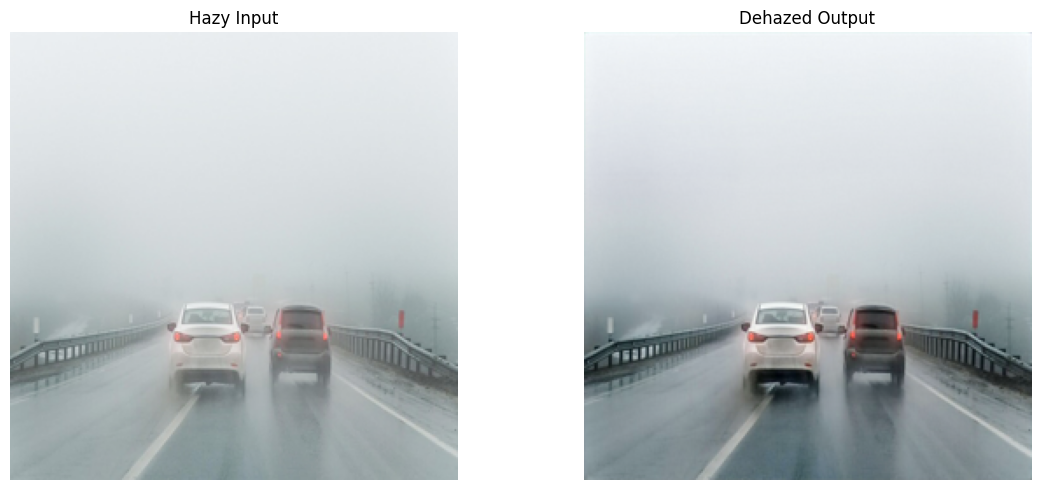

In [28]:
img = Image.open('fog.jpg').convert('RGB')
img = img.resize((256, 256))
img = np.array(img, dtype=np.float32) / 255.0
img = np.expand_dims(img, axis=0)

output = model.predict(img)

result = (output[0] * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img[0])
axes[0].set_title('Hazy Input')
axes[0].axis('off')

axes[1].imshow(output[0])
axes[1].set_title('Dehazed Output')
axes[1].axis('off')

plt.tight_layout()
plt.show()

1/1 [==============================] - 0s 32ms/step


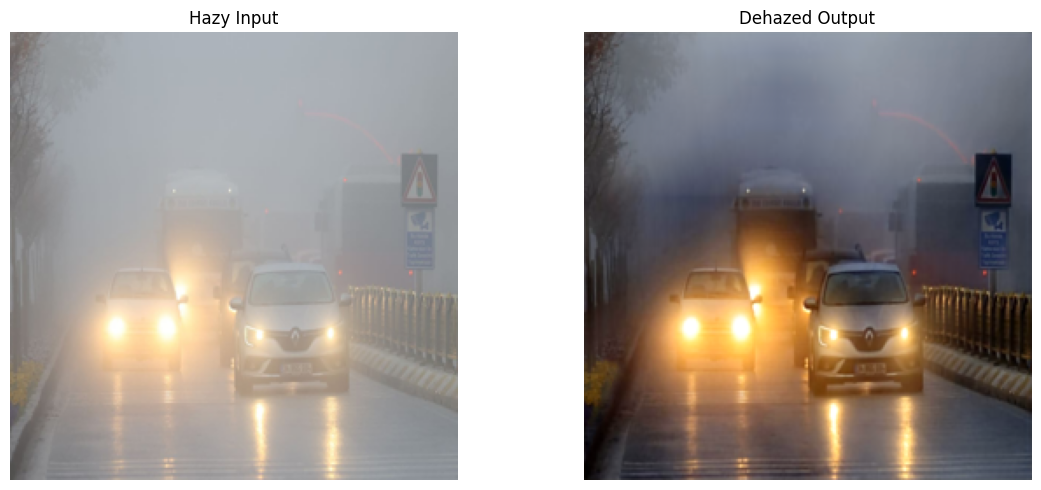

In [29]:
img = Image.open('fog2.jpg').convert('RGB') # from the RESIDE dataset
img = img.resize((256, 256))
img = np.array(img, dtype=np.float32) / 255.0
img = np.expand_dims(img, axis=0)

output = model.predict(img)

result = (output[0] * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img[0])
axes[0].set_title('Hazy Input')
axes[0].axis('off')

axes[1].imshow(output[0])
axes[1].set_title('Dehazed Output')
axes[1].axis('off')

plt.tight_layout()
plt.show()